# <center> **Отбор и селекция признаков**

>**Препроцессинг (preprocessing, предварительная обработка) в машинном обучении** — это важный шаг, который помогает повысить качество данных с целью извлечения из них значимых идей.

In [149]:
import pandas as pd
data = pd.read_csv('data_ml6/data_ford_price.csv',sep = ';')
data.head()

,price,year,condition,cylinders,odometer,title_status,transmission,drive,size,lat,long,weather
0,43900,2016,4,6,43500,clean,automatic,4wd,full-size,"36,4715","-82,4834",59.0
1,15490,2009,2,8,98131,clean,automatic,4wd,full-size,"40,468826","-74,281734",52.0
2,2495,2002,2,8,201803,clean,automatic,4wd,full-size,"42,477134","-82,949564",45.0
3,1300,2000,1,8,170305,rebuilt,automatic,4wd,full-size,"40,764373","-82,349503",49.0
4,13865,2010,3,8,166062,clean,automatic,4wd,NaN,"49,210949","-123,11472",NaN


In [150]:
def fix_lat_long(df: pd.DataFrame, lat_col: str = "lat", long_col: str = "long") -> pd.DataFrame:
    """
    Заменяет запятую на точку в указанных столбцах и конвертирует их в float.
    
    Параметры:
        df: входной DataFrame
        lat_col: имя столбца с широтой
        long_col: имя столбца с долготой
    
    Возвращает:
        DataFrame с исправленными столбцами (возвращается копия, исходный df не меняется)
    """
    df_fixed = df.copy()
    
    for col in [lat_col, long_col]:
        if col not in df_fixed.columns:
            raise ValueError(f"Столбец '{col}' не найден в DataFrame")
        
        # Приводим к строке, заменяем запятую на точку, конвертируем в float
        df_fixed[col] = (
            df_fixed[col]
            .astype(str)
            .str.replace(',', '.', regex=False)
            .astype(float, errors='ignore')  # если останется не-число, останется как есть
        )
        
        # Дополнительная очистка: если после replace всё ещё есть не-числа, превращаем в NaN
        df_fixed[col] = pd.to_numeric(df_fixed[col], errors='coerce')
    
    return df_fixed

In [151]:
data = fix_lat_long(data)

In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7017 entries, 0 to 7016
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         7017 non-null   int64  
 1   year          7017 non-null   int64  
 2   condition     7017 non-null   int64  
 3   cylinders     7017 non-null   int64  
 4   odometer      7017 non-null   int64  
 5   title_status  7017 non-null   object 
 6   transmission  7017 non-null   object 
 7   drive         6626 non-null   object 
 8   size          5453 non-null   object 
 9   lat           7017 non-null   float64
 10  long          7017 non-null   float64
 11  weather       6837 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 658.0+ KB


Для более подробного анализа числовых признаков используют методы ```describe()``` и ```hist()```. Для оценки распределения текстовых признаков можно воспользоваться методом ```value_counts()```.

---

Обратимся к нашим данным. Нас просят предсказать цену автомобиля. Для обучения модели выделим целевой столбец:

In [152]:
y = data['price']
x = data.drop(columns='price')

Попробуем применить линейную регрессию на «сырых» данных:

In [10]:
from sklearn import linear_model
lr = linear_model.LinearRegression()
lr.fit(x,y)

ValueError: could not convert string to float: 'clean'

Мы получим ошибку с комментарием о том, что не удалось превратить строковое значение в число с плавающей точкой (float).

Чтобы этой ошибки не возникало, необходимо закодировать данные.

Для реализации данных методов мы использовали библиотеку category_encoders. Однако вы уже знаете и такой мощный инструмент, как scikit-learn. Данная библиотека содержит набор реализованных алгоритмов машинного обучения, метрик для оценки их качества, а также  класс ```preprocessing``` для предобработки данных, в частности — для кодирования категориальных признаков.

Представленная ниже таблица показывает соответствие типа кодирования классу в ```sklearn.processing```

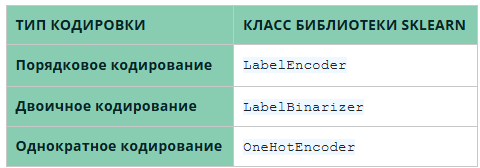

Преимущество использования одной библиотеки состоит в типичности методов. Например, вы знаете, что для обучения модели в sklearn используется метод ```fit()```. При кодировании признаков здесь также применяют ```fit()``` для подгонки кодировщика под выборку и ```transform()``` — для преобразования данных в числа.

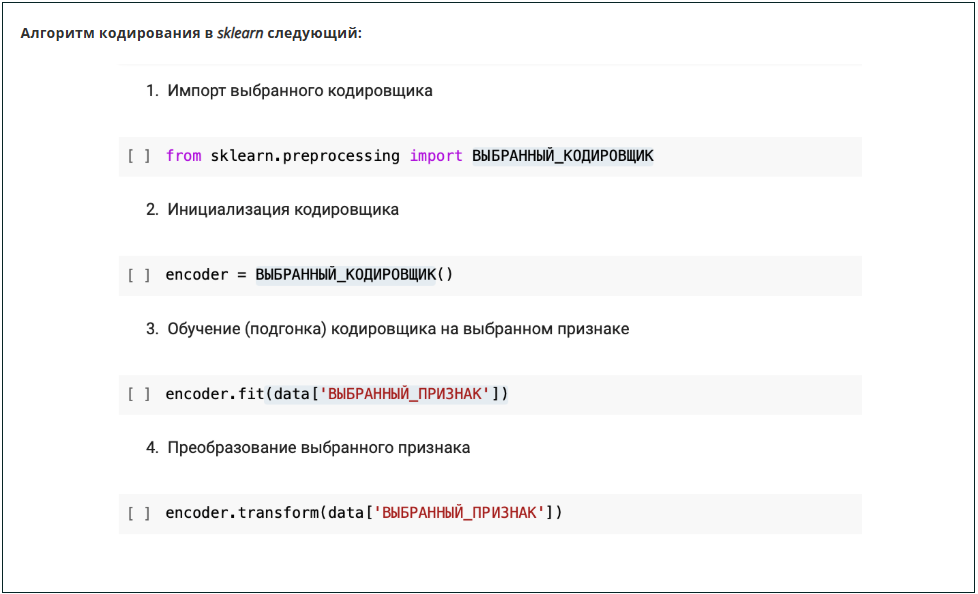

Из предыдущих модулей мы знаем, что при решении задач машинного обучения данные разбираются на обучающую (train) и валидационную (validation) выборки (последняя также может быть тестовой (test) выборкой). По аналогии подгонка кодировщика происходит на обучающей выборке, а трансформация — на обучающей и на тестовой.

Почему так? Потому что наша обученная модель не должна видеть данные, которые подаются в неё на тесте. Только так мы можем судить о том, что модель обучена качественно. То же самое и с кодировкой.

Давайте посмотрим на кодирование признака Образование способом «один-против-всех» (one vs all):

In [75]:
from sklearn.preprocessing  import LabelBinarizer
lb = LabelBinarizer()
education = ['нет', 'начальное', 'среднее', 'BSc', 'MSc', 'начальное', 'PhD']
lb.fit(education)
print('категории:', lb.classes_)
lb.transform(['нет', 'MSc'])

категории: ['BSc' 'MSc' 'PhD' 'начальное' 'нет' 'среднее']


array([[0, 0, 0, 0, 1, 0],
       [0, 1, 0, 0, 0, 0]])

У класса ```LabelBinarizer```, как и у двух остальных, есть атрибут ```classes_```, который выводит список уникальных значений признака.

Вернёмся к нашей выборке. В ней присутствуют следующие категориальные признаки: ```condition, cylinders, title_status, transmission, drive, size```.

При этом признаки ```condition``` и ```cylinders``` — числовые, а ```title_status, transmission, drive, size``` — текстовые.

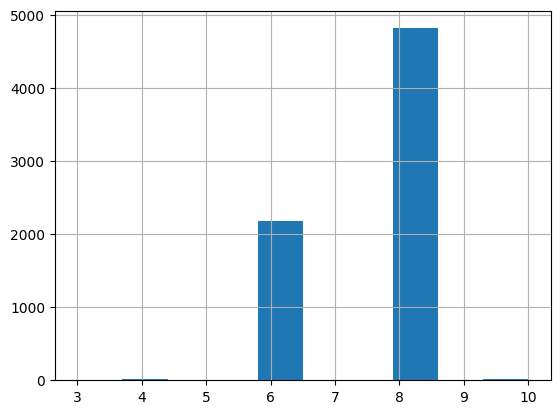

In [76]:
data['cylinders'].hist();

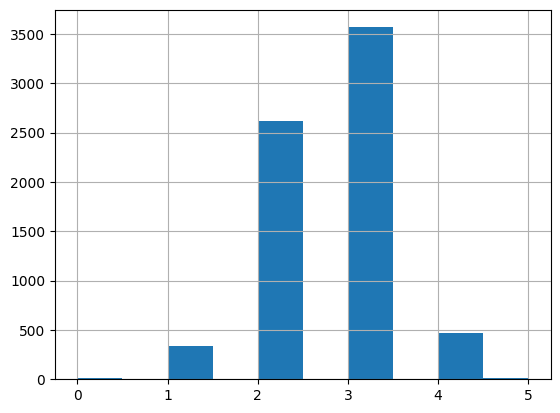

In [77]:
data['condition'].hist();

Посмотрим на число уникальных значений номинальных признаков ```title_status, transmission, drive, size и cylinders```:

In [78]:
columns_to_change = ['cylinders', 'title_status', 'transmission', 'drive', 'size']
 
for column in columns_to_change:
    print('Число уникальных значений признака {}: '.format(column), data[column].nunique())

Число уникальных значений признака cylinders:  6
Число уникальных значений признака title_status:  5
Число уникальных значений признака transmission:  3
Число уникальных значений признака drive:  3
Число уникальных значений признака size:  4


Итак, нам подходит однократное кодирование. Применим его к выбранным столбцам. Так как у нас нет отдельной тестовой выборки, то мы используем только один метод — ```fit_transform()```. В качестве аргумента передаём таблицу с выбранными для преобразования признаками.

С помощью метода ```get_feature_names_out()``` получим список новых названий колонок:

In [79]:
from sklearn.preprocessing import OneHotEncoder
 
one_hot_encoder = OneHotEncoder()
 
# 'учим' и сразу применяем преобразование к выборке, результат переводим в массив
data_onehot = one_hot_encoder.fit_transform(data[columns_to_change]).toarray()
 
# запишем полученные названия новых колонок в отдельную переменную
column_names = one_hot_encoder.get_feature_names_out(columns_to_change)
print(column_names)

['cylinders_3' 'cylinders_4' 'cylinders_5' 'cylinders_6' 'cylinders_8'
 'cylinders_10' 'title_status_clean' 'title_status_lien'
 'title_status_missing' 'title_status_rebuilt' 'title_status_salvage'
 'transmission_automatic' 'transmission_manual' 'transmission_other'
 'drive_4wd' 'drive_fwd' 'drive_rwd' 'drive_nan' 'size_compact'
 'size_full-size' 'size_mid-size' 'size_sub-compact' 'size_nan']


Отлично, категориальные признаки закодированы. Теперь нам необходимо соединить преобразованные данные с исходными.

Напомним, что у библиотеки pandas есть дефолтный метод ```get_dummies()``` для получения однократного кодирования признаков. Однако OneHotEncoder способен принимать на вход как таблицы, так и numpy-массивы.

In [80]:
data_onehot = pd.DataFrame(data_onehot, index=data.index, columns=column_names)
data_new = pd.concat([data, data_onehot], axis=1)
data_new = data_new.drop(columns=columns_to_change)

In [81]:
data_new.shape

(7017, 30)

---

## <center> РАБОТА С ПРОПУСКАМИ

In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7017 entries, 0 to 7016
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         7017 non-null   int64  
 1   year          7017 non-null   int64  
 2   condition     7017 non-null   int64  
 3   cylinders     7017 non-null   int64  
 4   odometer      7017 non-null   int64  
 5   title_status  7017 non-null   object 
 6   transmission  7017 non-null   object 
 7   drive         6626 non-null   object 
 8   size          5453 non-null   object 
 9   lat           7017 non-null   float64
 10  long          7017 non-null   float64
 11  weather       6837 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 658.0+ KB


Для того чтобы выделить конкретные строки датасета, в столбцах которых присутствуют NaN (пропуски), используются уже знакомые вам методы ```isnull()```

Метод ```isnull()``` является алиасом метода ```isna()```: когда вы используете isnull(), он вызывает isna(). Таким образом, это два одинаковых метода.

Зачем им нужны разные названия?

Дело в том, что ```Pandas DataFrame``` основан на таблицах языка программирования R. В R значения ```na``` и нулевые значения относятся к разным типам. Следовательно, есть два разных метода проверки: ```na``` и ```null```. Вот почему в Pandas есть два имени для одного метода.

С другой стороны, в Python библиотека Pandas построена поверх ```NumPy```, у которой нет значений ```na``` или ```null```. NumPy использует значения ```np.NaN``` для обозначения отсутствующих данных. Даже значения None считаются np.NaN.

Посмотрим, что будет, если просто убрать все строки с пропусками в столбце weather:

In [83]:
data[~data['weather'].isna()]

,price,year,condition,cylinders,odometer,title_status,transmission,drive,size,lat,long,weather
0,43900,2016,4,6,43500,clean,automatic,4wd,full-size,36.471500,-82.483400,59.0
1,15490,2009,2,8,98131,clean,automatic,4wd,full-size,40.468826,-74.281734,52.0
2,2495,2002,2,8,201803,clean,automatic,4wd,full-size,42.477134,-82.949564,45.0
3,1300,2000,1,8,170305,rebuilt,automatic,4wd,full-size,40.764373,-82.349503,49.0
5,6995,2003,3,8,167662,clean,automatic,4wd,full-size,45.518031,-122.578752,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...
7012,22500,2015,3,6,23500,clean,automatic,rwd,full-size,32.680700,-117.169800,59.0
7013,5975,2005,2,8,0,clean,automatic,rwd,full-size,38.213303,-85.785762,50.0
7014,9999,2006,3,8,161514,clean,automatic,NaN,full-size,37.609783,-120.995406,59.0
7015,10900,2011,2,8,164000,clean,automatic,4wd,full-size,43.140600,-93.385000,47.0


>Символ ~ (тильда) означает, что мы выбираем все строки датасета data, где не выполняется условие data['weather'].isna(), то есть где нет пропусков в столбце 'weather'.

In [84]:
print(f'Если убрать пропуски в столбце size,в датасете останется',round(data[~data['size'].isna()].shape[0]/data.shape[0],2), 'строк от общего количества')

Если убрать пропуски в столбце size,в датасете останется 0.78 строк от общего количества


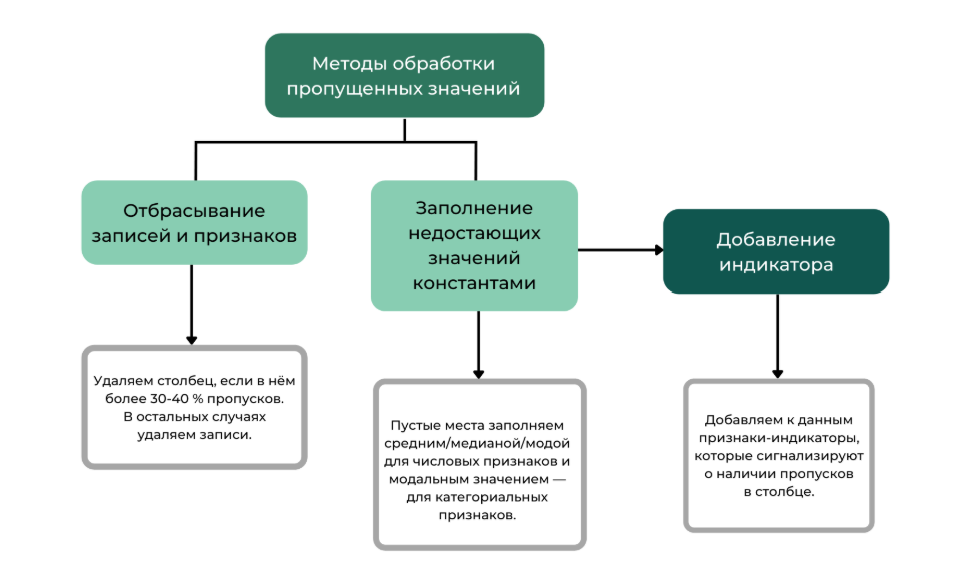

Первым делом воспользуемся методом удаления строк с пропусками. Плюс данного метода состоит в том, что модель, обученная с удалением всех пропущенных значений, является надёжной, то есть имеет сравнительно хорошее качество на тесте. Среди минусов — потеря большого количества информации, а также плохое качество работы, если процент отсутствующих значений слишком велик по сравнению с полным набором данных.

В качестве регрессора воспользуемся линейной моделью, а качество оценим с помощью коэффициента детерминации. Также нам потребуется разделить модель на обучающую и тестовую выборки.

In [85]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

Удалим данные с пропусками:

In [86]:
x = x.dropna()

Мы удалили некоторые строки из таблицы x. Соответственно, надо сделать то же самое в целевой переменной y.

Выберем все оставшиеся индексы таблицы x с помощью метода ```index()```, а затем используем ```.iloc[]```, чтобы получить подгруппу целевых значений, соответствующую полученным индексам.

In [87]:
y = y.iloc[x.index]

In [88]:
x.shape[0]==y.shape[0]

True

In [89]:
# Разделим выборку на тренировочную и тестовую в соотношении 80/20:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=30)

In [90]:
# Проведём кодирование OneHot-методом категориальных переменных.
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder()

In [91]:
# Обучаем энкодер и сразу применяем преобразование к выборке. Результат переводим в массив:
X_train_onehot = one_hot_encoder.fit_transform(X_train[columns_to_change]).toarray()

In [92]:
# Затем применяем полученное преобразование к тестовой выборке. Результат переводим в массив:
X_test_onehot = one_hot_encoder.transform(X_test[columns_to_change]).toarray()

In [93]:
# Для удобства сохраним полученные названия новых колонок в отдельную переменную:
columns = one_hot_encoder.get_feature_names_out(columns_to_change)
columns[:10]

array(['cylinders_3', 'cylinders_4', 'cylinders_5', 'cylinders_6',
       'cylinders_8', 'cylinders_10', 'title_status_clean',
       'title_status_lien', 'title_status_missing',
       'title_status_rebuilt'], dtype=object)

In [94]:
# Теперь у нас есть массив закодированных признаков и наша изначальная таблица. Чтобы соединить эти данные, переведём массив в формат DataFrame.
X_train_onehot_df = pd.DataFrame(X_train_onehot, columns=columns)
X_test_onehot_df = pd.DataFrame(X_test_onehot, columns=columns)

Переустановим индексацию в таблицах, применив подряд сразу два метода: reset_index() — для изменения индексов с рандомных на последовательные от 0 до n и drop(['index'], axis = 1) — для удаления образовавшегося столбца 'index'.

In [95]:
X_train = X_train.reset_index().drop(['index'], axis = 1)
X_test = X_test.reset_index().drop(['index'], axis = 1)
 
y_train = y_train.reset_index().drop(['index'], axis = 1)
y_test = y_test.reset_index().drop(['index'], axis = 1)

Объединяем таблицы и удаляем старые категориальные признаки:

In [96]:
X_train_new = pd.concat([X_train, X_train_onehot_df], axis=1)
X_test_new = pd.concat([X_test, X_test_onehot_df], axis=1)
 
X_train_new = X_train_new.drop(columns=columns_to_change)
X_test_new = X_test_new.drop(columns=columns_to_change)

Настало время обучить модель. Для этого создаём объект класса LinearRegression.

In [97]:
lr_model = LinearRegression()

lr_model.fit(X_train_new, y_train)
y_train_predict = lr_model.predict(X_train_new)
y_test_predict = lr_model.predict(X_test_new)
print("Train R^2: {:.3f}".format(r2_score(y_train, y_train_predict)))
print("Test R^2: {:.3f}".format(r2_score(y_test, y_test_predict)))


Train R^2: 0.647
Test R^2: 0.693


В признаках lat и long есть незакодированные данные. Почему-то в модуле эти признаки не учитываются. модель их не принимает

Теперь давайте попробуем заполнить пропуски константными значениями и обучить модель заново. Плюс такого подхода состоит в том, что мы предотвращаем потерю данных, которая происходит при удалении строк или столбцов. Основной минус — в снижении разброса (разнообразия) признаков.

Заполним числовой столбец средним значением, округлив его до целого числа:

In [98]:
import numpy as np
 
X_train['weather'] = X_train['weather'].fillna(np.round(np.mean(X_train['weather']),0))
X_test['weather'] = X_test['weather'].fillna(np.round(np.mean(X_train['weather']),0))

Для простоты воспользуемся заполнением наиболее частым значением категориальных признаков. Для этого сначала определим их в наших признаках, использовав комбинацию методов value_counts() и head():

In [99]:
X_train['drive'].value_counts(True).head(1)

drive
4wd    0.736602
Name: proportion, dtype: float64

In [100]:
X_train['size'].value_counts(True).head(1)

size
full-size    0.830089
Name: proportion, dtype: float64

In [101]:
X_train['size'] = X_train['size'].fillna('full-size')
X_train['drive'] = X_train['drive'].fillna('4wd')
 
X_test['size'] = X_test['size'].fillna('full-size')
X_test['drive'] = X_test['drive'].fillna('4wd')

После обучения модели получился следующий результат:
```python
# Train R^2: 0.649
# Test R^2: 0.465

>Напомним: модели с коэффициентом детерминации выше 0.8 можно признать достаточно хорошими. Равенство коэффициента детерминации 1 означает, что объясняемая переменная в точности описывается рассматриваемой моделью.

Приведённые методы обработки отсутствующих значений не учитывают корреляционную связь признака, содержащего пропуски, с остальными. Признаки, не имеющие NaN, можно использовать для прогнозирования пропущенных значений. Строится модель регрессии или классификации в зависимости от характера (категорийного или непрерывного) признака, имеющего пропущенное значение.

In [117]:
# Импортируем необходимые модули
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

# Скопируем данные в отдельную переменную
data = x.copy()
 
# В качестве тестовой выборки возьмем строки с пропусками в признаке weather
test_data = data[data['weather'].isnull()]
# И удалим эти строчки из таблицы
data.dropna(inplace=True)

# Определим целевой признак и факторы
y_train = data['weather']
X_train = data.drop(['size','weather','drive'], axis=1)
X_test = test_data.drop(['size','weather','drive'], axis=1)

# Создадим кодировщик
one_hot_encoder = OneHotEncoder()
categorial_cols = ['cylinders', 'title_status', 'transmission']

# Закодируем категориальные признаки (обучаем кодировщик только на тренировочной выборке)
X_train_onehot = one_hot_encoder.fit_transform(X_train[categorial_cols]).toarray()
X_test_onehot = one_hot_encoder.transform(X_test[categorial_cols]).toarray()

# Результаты преобразуем обратно в DataFrame для удобства
columns = one_hot_encoder.get_feature_names_out(categorial_cols)
X_train_onehot_df = pd.DataFrame(X_train_onehot, columns=columns)
X_test_onehot_df = pd.DataFrame(X_test_onehot, columns=columns)

# Сбросим индексы таблиц
X_train = X_train.reset_index().drop(['index'], axis = 1)
X_test = X_test.reset_index().drop(['index'], axis = 1)
y_train = y_train.reset_index().drop(['index'], axis = 1)

# Добавим результаты кодирования к исходным таблицам
X_train_new = pd.concat([X_train, X_train_onehot_df], axis=1)
X_test_new = pd.concat([X_test, X_test_onehot_df], axis=1)

# Удалим столбцы, которые уже были закодированы
X_train_new = X_train_new.drop(columns=categorial_cols)
X_test_new = X_test_new.drop(columns=categorial_cols)

# Создадим модель линейной регрессии и обучим ее на задачу предсказания пропусков
model = LinearRegression()
model.fit(X_train_new, y_train)

# Сделаем предсказание целевой переменной (пропущенных значений в признаке weather) 
y_pred = model.predict(X_test_new)

In [118]:
y_pred

array([[ 40.91435555],
       [ 40.7637233 ],
       [ 39.74866152],
       [ 41.2755305 ],
       [ 40.31791932],
       [ 41.10796547],
       [ 41.15337846],
       [ 39.94866488],
       [ 41.10796547],
       [ 40.7217165 ],
       [ 40.18904454],
       [ 91.62094167],
       [ 41.12549856],
       [ 41.33052316],
       [ 39.66827354],
       [ 40.91435555],
       [ 40.77287826],
       [ 40.84208674],
       [ 41.10796547],
       [ 41.02118034],
       [ 40.31791932],
       [ 41.30309209],
       [ 40.77645269],
       [ 40.75842615],
       [ 40.61605044],
       [ 40.79031628],
       [ 40.7701239 ],
       [ 39.78723017],
       [ 41.27231621],
       [ 39.77492057],
       [ 40.7637233 ],
       [ 40.7701239 ],
       [ 41.10796547],
       [ 39.68313064],
       [ 40.12277414],
       [ 39.7873657 ],
       [ 41.07798631],
       [ 41.06812063],
       [ 40.7637233 ],
       [ 40.90194049],
       [ 41.10796547],
       [ 70.85737739],
       [ 30.44339508],
       [ 40

Полученные предсказания есть не что иное, как замена пропусков в столбце weather:

---

## <center> РАБОТА С ВЫБРОСАМИ

Помимо пропусков, на пути анализа данных всплывает ещё один подводный камень — **выбросы (аномалии)**.

Выбросы могут искажать статистические показатели и распределения данных. Удаление выбросов из обучающих данных перед моделированием может привести к росту качества прогнозов.

К счастью, существуют автоматические, основанные на моделях методы выявления выбросов, которые уже имплементированы в sklearn.

In [124]:
data = data[['price', 'year', 'cylinders', 'odometer' ,'lat', 'long', 'weather']]
data.dropna(inplace = True)
 
y = data['price']
x = data.drop(columns='price')
x.head()

,year,cylinders,odometer,lat,long,weather
0,2016,6,43500,36.471500,-82.483400,59.0
1,2009,8,98131,40.468826,-74.281734,52.0
2,2002,8,201803,42.477134,-82.949564,45.0
3,2000,8,170305,40.764373,-82.349503,49.0
5,2003,8,167662,45.518031,-122.578752,50.0


In [125]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=40)

model = LinearRegression()
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)
 
mae = mean_absolute_error(y_test, y_predicted)
print('MAE: %.3f' % mae)

MAE: 4682.957


1. Первый алгоритм, который мы применим, — **Isolation Forest**, или **iForest**. Это алгоритм обнаружения аномалий на основе дерева.

Данный метод стремится изолировать аномалии, которые немногочисленны и различаются по пространству признаков.

Библиотека *scikit-learn* предоставляет реализацию *Isolation Forest* в классе **IsolationForest**.

Одним из основных гиперпараметров модели является ```contamination``` («загрязнение»), который используется для оценки количества выбросов в наборе данных. Его значение находится в диапазоне от 0.0 до 0.5 и по умолчанию равно 0.1.

In [126]:
from  sklearn.ensemble import IsolationForest
 
# ищем выбросы в обучающей выборке
iso = IsolationForest(contamination=0.1)
y_predicted = iso.fit_predict(X_train)
 
# выберем все строки, которые не являются выбросами
mask = y_predicted != -1
X_train, y_train = X_train[mask], y_train[mask]
 
print(X_train.shape, y_train.shape)
 
model = LinearRegression()
model.fit(X_train, y_train)
 
y_predicted = model.predict(X_test)
mae = mean_absolute_error(y_test, y_predicted)
print('MAE: %.3f' % mae)

(4307, 6) (4307,)
MAE: 4422.931


2. Следующий метод — **Local Outlier Factor**, или **LOF**. Это метод, который пытается использовать идею ближайших соседей для обнаружения выбросов.

>Каждому примеру присваивается оценка того, насколько он изолирован от его локальных соседей. Примеры, которые наиболее отдалены от соседей, скорее всего, будут являться выбросами.

Библиотека *scikit-learn* обеспечивает реализацию этого подхода в классе **LocalOutlierFactor**.

In [127]:
from sklearn.neighbors import LocalOutlierFactor
 
lof = LocalOutlierFactor()
y_predicted = lof.fit_predict(X_train)

mask = y_predicted != -1
X_train, y_train = X_train[mask], y_train[mask]
 
print(X_train.shape, y_train.shape)
 
model = LinearRegression()
model.fit(X_train, y_train)
 
y_predicted = model.predict(X_test)
mae = mean_absolute_error(y_test, y_predicted)
print('MAE: %.3f' % mae)

(3972, 6) (3972,)
MAE: 4423.279


c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


3. Напоследок рассмотрим **Minimum Covariance Determinant**, или **MCD**.

Если входные переменные имеют гауссово распределение, то для обнаружения выбросов можно использовать простые статистические методы.

Например, если набор данных имеет две входные переменные и обе они являются гауссовыми, то пространство признаков образует многомерную гауссовскую зависимость, и знание этого распределения можно использовать для определения значений, далёких от распределения.

>Этот подход можно обобщить, определив гиперсферу (эллипсоид), которая покрывает нормальные данные, а данные, выходящие за пределы этой формы, считаются выбросами. Эффективная реализация этого метода для многомерных данных известна как **детерминант минимальной ковариации (MCD)**.

Библиотека scikit-learn предоставляет доступ к этому методу через класс **EllipticEnvelope**.

In [128]:
from sklearn.covariance import EllipticEnvelope
 
ee = EllipticEnvelope(contamination=0.01)
y_predicted = ee.fit_predict(X_train)

mask = y_predicted != -1
X_train, y_train = X_train[mask], y_train[mask]
 
print(X_train.shape, y_train.shape)
 
model = LinearRegression()
model.fit(X_train, y_train)
 
y_predicted = model.predict(X_test)
mae = mean_absolute_error(y_test, y_predicted)
print('MAE: %.3f' % mae)

(3934, 6) (3934,)
MAE: 4427.830


>Данные алгоритмы носят стохастический характер, поэтому результаты метрики могут отличаться от прогона к прогону.

Мы видим, что оптимальный результат достигается с помощью древовидного алгоритма *Isolation Forest*, тогда как пространственные методы LOF и MCD принимают за выбросы больше данных, что приводит к ухудшению качества. Тем не менее все три метода превосходят baseline.

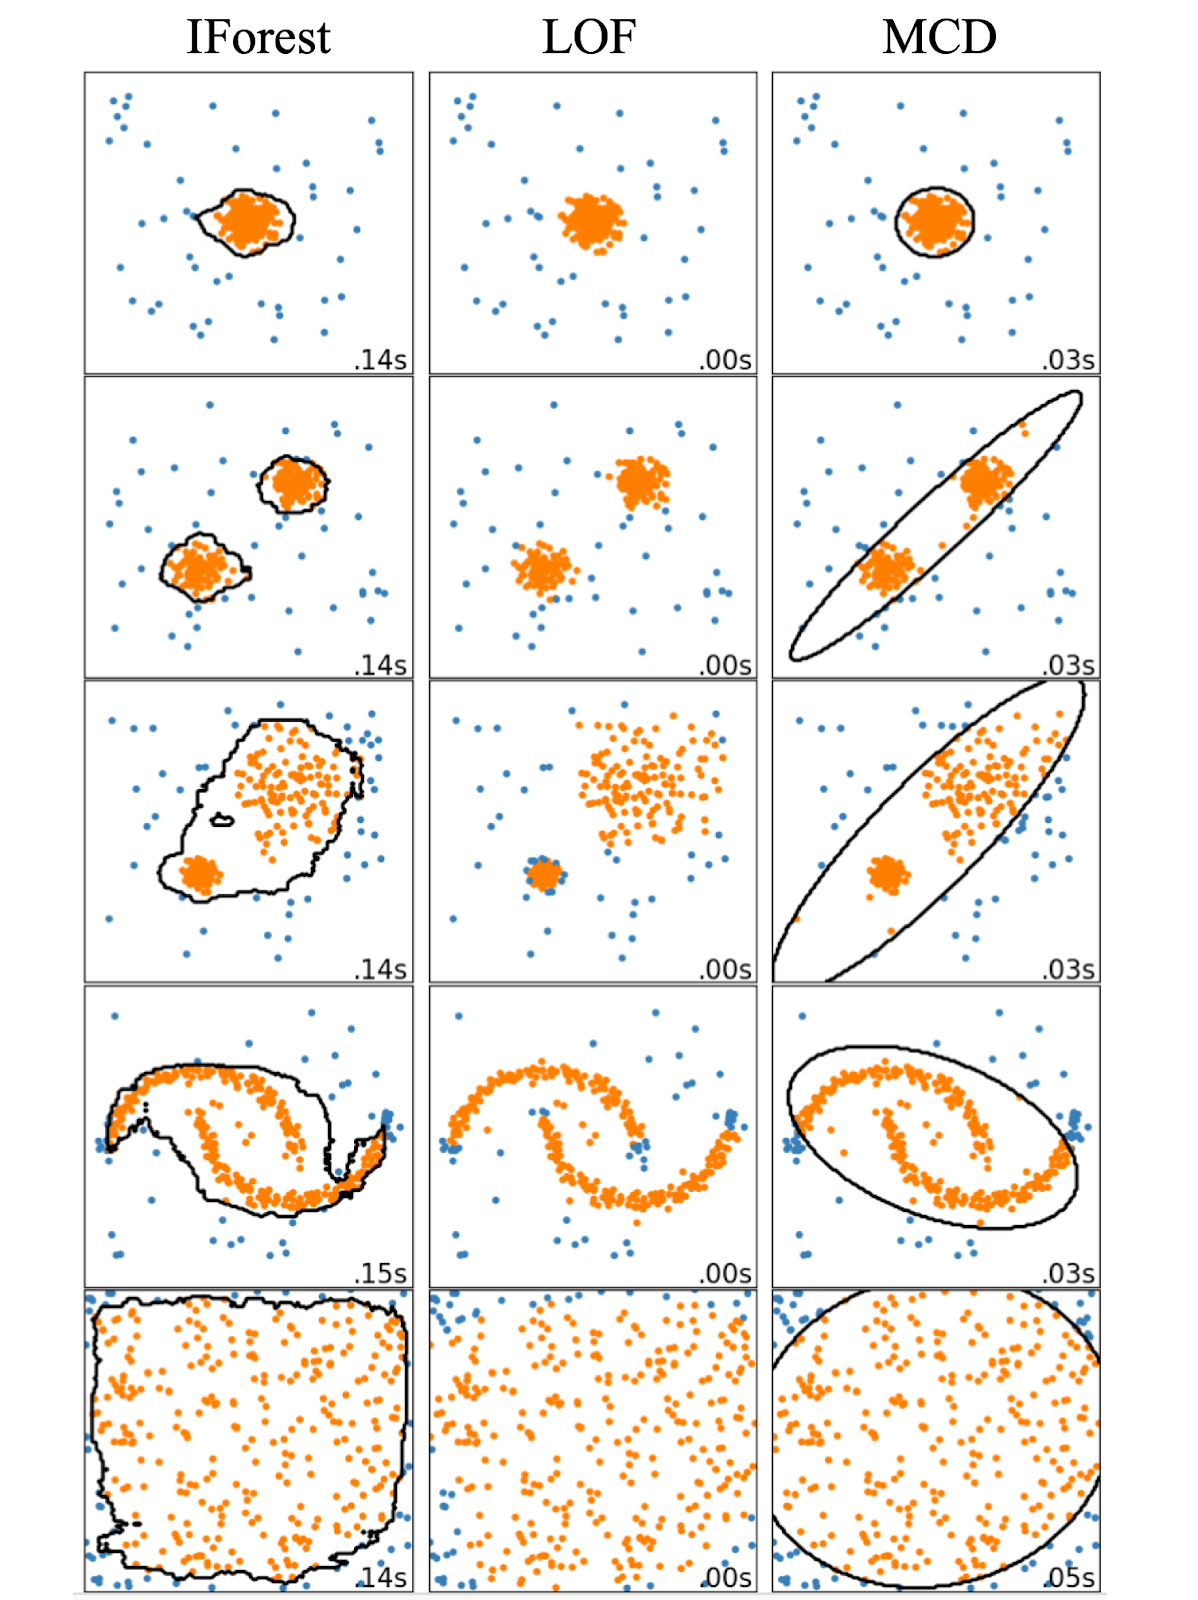

---

## <center> Масштабирование признаков

Давайте посмотрим, как StandardScaler, MinMaxScaler и RobustScaler справятся с нашими данными. Для наглядности будем использовать три столбца.

In [142]:
data = data[['price', 'year', 'weather']]
data.dropna(inplace = True)
data_scaled = data.copy()
col_names = ['price', 'weather']
x = data_scaled[col_names]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
 
data_scaled[col_names] = scaler.fit_transform(x.values)
data_scaled

,price,year,weather
0,2.558728,2016,0.862068
1,0.067373,2009,-0.017965
2,-1.072197,2002,-0.897998
3,-1.176990,2000,-0.395122
5,-0.677579,2003,-0.269403
...,...,...,...
7012,0.682100,2015,0.862068
7013,-0.767025,2005,-0.269403
7014,-0.414149,2006,0.862068
7015,-0.335138,2011,-0.646560


In [143]:
y = data_scaled['year']
x = data_scaled.drop(columns='year')

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=40)
 
model = LinearRegression()
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)
 
mae = mean_absolute_error(y_test, y_predicted)
print('MAE: %.3f' % mae)

MAE: 3.041


Задание 5.2
1/1 point (graded)

Отмасштабируйте признак price с помощью RobustScaler.
В качестве ответа запишите результат выполнения кода data['price'][1]. Ответ округлите до двух знаков после точки-разделителя.

In [144]:
data = data[['price']]
data.dropna(inplace = True)
data_scaled = data.copy()
col_names = ['price']
x = data_scaled[col_names]

from sklearn.preprocessing import RobustScaler
scaler = preprocessing.RobustScaler()
data_scaled[col_names] = scaler.fit_transform(x.values)
data_scaled

,price
0,1.982455
1,0.189460
2,-0.630672
3,-0.706090
5,-0.346671
...,...
7012,0.631871
7013,-0.411044
7014,-0.157084
7015,-0.100221


In [148]:
print(f'Результат масштабированного признака Price под индексом 1- ',round(data_scaled['price'][1], 2))

Результат масштабированного признака Price под индексом 1-  0.19


---

# <center> **Quantile Transformer**

Этот [метод](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html) трансформации признаков преобразует распределение переменной в нормальное или равномерное распределение и масштабирует его соответствующим образом.

>**Квантильное преобразование** сопоставляет распределение вероятностей переменной с другим распределением вероятностей с использованием квантильной функции.

>**Квантильная функция**, также называемая **функцией процентной точки (PPF)**, является обратной функцией кумулятивного распределения вероятностей (CDF).

>**CDF** — это функция, которая возвращает вероятность значения, равного или меньше заданного значения.

PPF является инверсией этой функции и возвращает значение с заданной вероятностью или ниже неё.

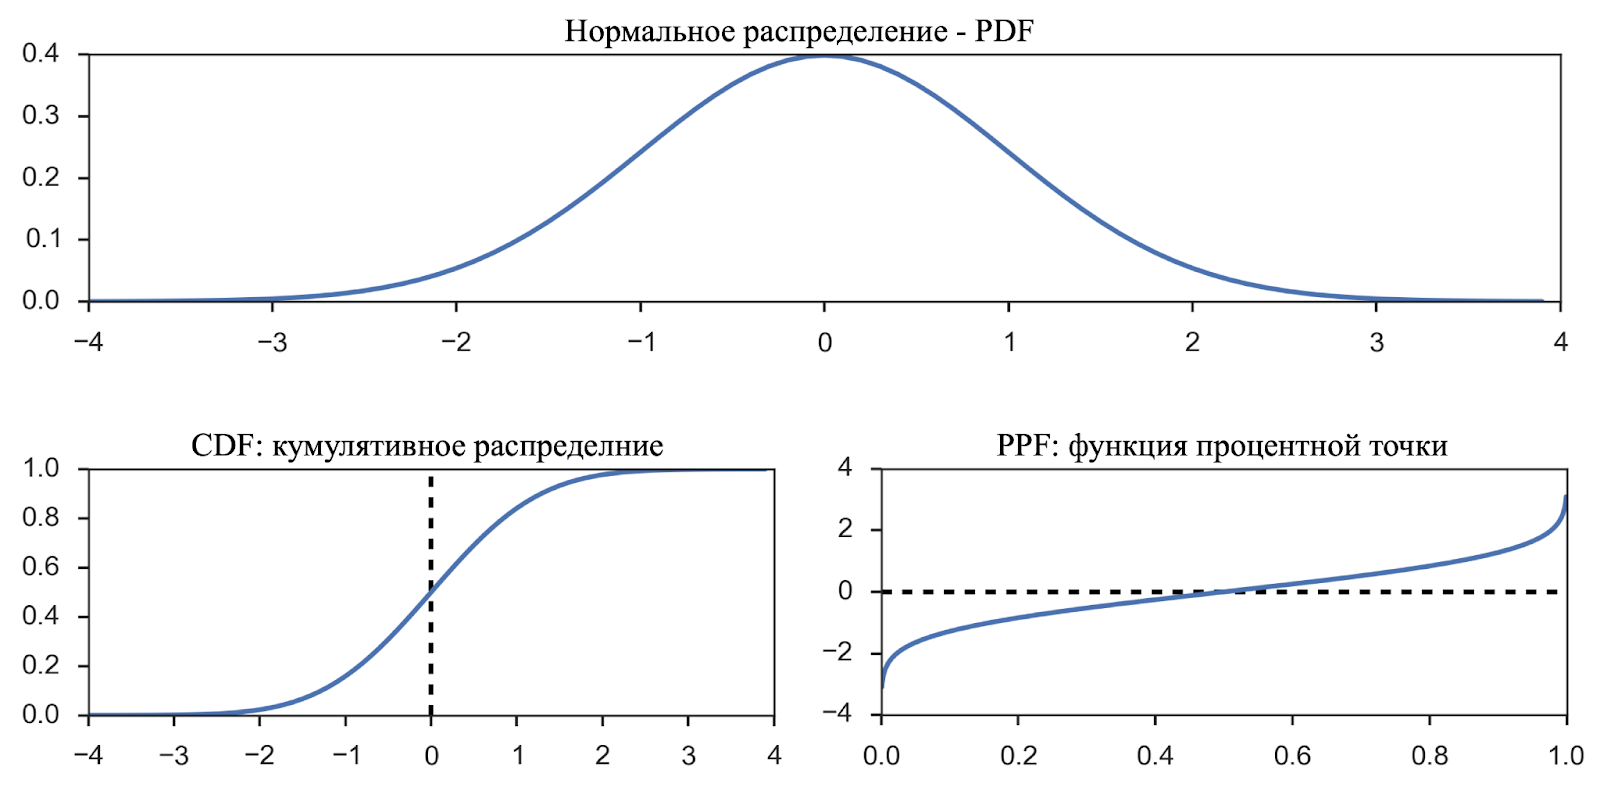

Квантильная функция ранжирует или сглаживает взаимосвязь между наблюдениями и может быть отображена на другие распределения (равномерное или нормальное).

Это квантильное преобразование доступно в библиотеке машинного обучения Python *scikit-learn* через класс [QuantileTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html).

У класса есть аргумент ```output_distribution```, который отвечает за тип выходного распределения. Он может принимать значение ```'uniform'``` (равномерное распределение) или ```'normal'``` (нормальное распределение). По умолчанию используется равномерное распределение, то есть значение параметра равно 'uniform'.

Гиперпараметр ```n_quantiles``` определяет разрешение отображения или ранжирование наблюдений в наборе данных. Это значение должно быть меньше, чем количество наблюдений в наборе данных, и по умолчанию равно 1000.

>Поскольку этот метод изменяет само распределение переменных, из-за этого скейлера линейные отношения между переменными могут быть разрушены. Таким образом, лучше всего использовать его для нелинейных данных.

Применим данное преобразование к признаку ```year```. Для начала посмотрим на его распределение.

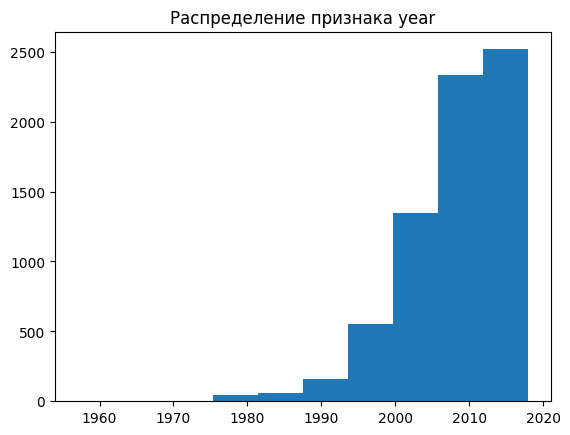

In [153]:
import matplotlib.pyplot as plt
 
plt.hist(data.year)
plt.title('Распределение признака year');

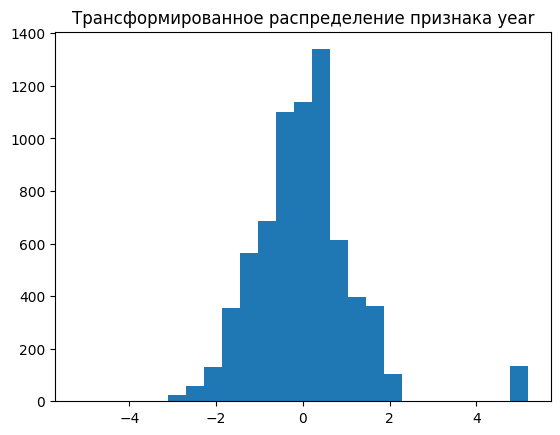

In [154]:
from sklearn.preprocessing import QuantileTransformer
# Данный трансформер принимает на вход 2D-массив, поэтому нам надо изменить формат данных (поскольку мы подаём на вход только один столбец)
data_for_transform = data['year'].values.reshape((len(data),1))
 
quantile = QuantileTransformer(output_distribution='normal')
data_transformed = quantile.fit_transform(data_for_transform)
 
plt.hist(data_transformed, bins=25)
plt.title('Трансформированное распределение признака year')
plt.show()

Задание 6.1
1 point possible (graded)

Преобразуйте распределение признаков condition и cylinders в равномерное. Какое значение признака condition получится у нулевого объекта? Ответ округлите до второго знака после точки-разделителя.

In [161]:
data_for_transform = data['condition'].values.reshape((len(data),1))
 
quantile = QuantileTransformer(output_distribution='uniform')
data_transformed = quantile.fit_transform(data_for_transform)
 
print(f'значение признака condition получится у нулевого объекта - ',data_transformed[0].round(2))

значение признака condition получится у нулевого объекта -  [0.96]


In [162]:
data_for_transform = data['cylinders'].values.reshape((len(data),1))
 
quantile = QuantileTransformer(output_distribution='uniform')
data_transformed = quantile.fit_transform(data_for_transform)
 
print(f'значение признака cylinders получится у нулевого объекта - ',data_transformed[0].round(2))

значение признака cylinders получится у нулевого объекта -  [0.16]


---

# <center> **Log Transform**

**Логарифмическое преобразование** — один из самых популярных методов преобразования. В основном оно используется для превращения асимметричного распределения в нормальное/менее асимметричное. В этом преобразовании мы берём логарифм значений признака вместо самих значений.

Почему это работает? Потому что функция логарифма создана для работы с большими числами.

Посмотрим на распределение признака ```price```. Оно асимметрично, причём значения варьируются от 0 до ~300000

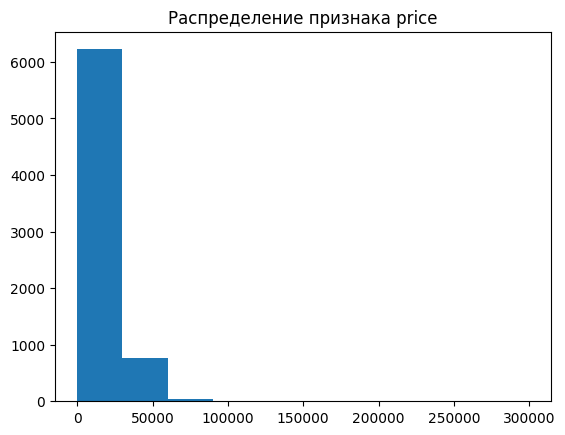

In [163]:
plt.hist(data.price)
plt.title('Распределение признака price');

Идеальный кандидат для логарифмического преобразования — применим его. На этот раз обойдёмся силами numpy.

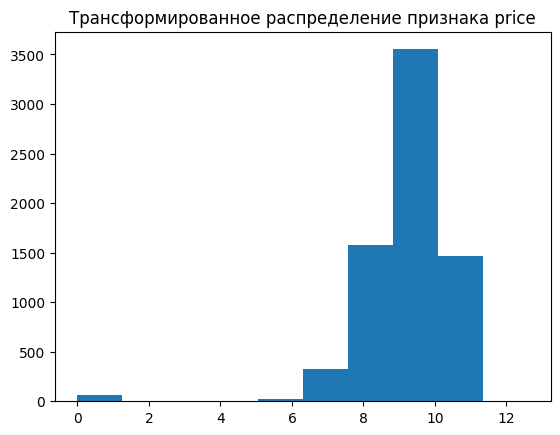

In [164]:
log_price = np.log(data['price'])
 
plt.hist(log_price)
plt.title('Трансформированное распределение признака price')
plt.show()

Давайте также сравним значения исходного и трансформированного признака.

In [165]:
price_data = pd.concat([data['price'], log_price.rename('transformed_price')], axis = 1)
 
price_data.describe()

,price,transformed_price
count,7017.000000,7017.000000
mean,15121.549523,9.204510
std,11765.423119,1.275868
min,1.000000,0.000000
25%,5995.000000,8.698681
50%,12750.000000,9.453287
75%,21995.000000,9.998570
max,299500.000000,12.609870


Теперь вместо экстремального разброса значений в 1 и 299500 мы получили 0 и 12.6. Таким образом, логарифмическое преобразование сыграло роль в уменьшении влияния слишком низких и слишком высоких значений.

>Стоит учесть, что, если наши данные имеют отрицательные значения или значения в диапазоне от 0 до 1, мы не можем применить логарифмическое преобразование напрямую, поскольку логарифм отрицательных чисел и 0 не определён, то есть мы получим ошибки или значения NaN в наших данных. В таких случаях мы можем добавить число к этим значениям, чтобы все они были больше 1.

In [173]:
print(f'Последний объект признака transformed_price имеет значение - ', round(price_data['transformed_price'].iloc[-1],1))

Последний объект признака transformed_price имеет значение -  9.8


---

# <center> **Power Transformer Scaler**

Как и другие скейлеры, с которыми вы уже познакомились, *Power Transformer* также изменяет распределение переменной, то есть делает его более гауссовым (нормальным).

Однако чтобы использовать все изученные раннее методы трансформации и скейлинга, необходимо сначала понять исходное распределение признака, а затем уже делать выбор. *Power Transformer* фактически автоматизирует принятие этого решения, вводя параметр, называемый **lambda**. Он принимает решение об обобщённом степенном преобразовании, находя наилучшее значение **lambda** и используя один из следующих параметрических методов:
* **Преобразование Бокса-Кокса**, которое работает для положительных значений признака.
* **Преобразование Йео-Джонсона**, которое учитывает при расчётах нулевые и отрицательные значения обрабатываемых переменных.

В нашем случае мы будем использовать преобразование Бокса-Кокса, так как все значения положительны.

In [180]:
import pandas as pd
from sklearn.preprocessing import PowerTransformer

# Предположим, что data — это DataFrame с колонками 'price' и 'year'
# Проверим наличие и корректность данных
if 'price' not in data.columns or 'year' not in data.columns:
    raise ValueError("В DataFrame отсутствуют колонки 'price' и 'year'")

# Проверим, есть ли отрицательные значения или нули
if (data[['price', 'year']] <= 0).any().any():
    raise ValueError("Для применения Box-Cox все значения должны быть положительными")

# Преобразование с помощью PowerTransformer
box_cox = PowerTransformer(method='box-cox')

# Создадим копию ДФ для проеобразования boxcox scipy
test_data_year = data.copy()

from scipy.stats import boxcox

data_box_cox_price = box_cox.fit_transform(data[['price']].values)

data_box_cox_year, lambda_year  = boxcox(test_data_year['year'])

# Создадим DataFrame с преобразованными данными
data_box_cox_price = pd.DataFrame(data_box_cox_price, columns=['transformed_price'])
data_box_cox_year = pd.DataFrame(data_box_cox_year, columns=['transformed_year'])

data_box_cox = pd.concat([data_box_cox_price, data_box_cox_year], axis=1)

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_morestats.py:1153: UserWarning: The optimal lambda is 123.77781881071438, but the returned lambda is the constrained optimum to ensure that the maximum or the minimum of the transformed data does not overflow in <class 'numpy.float64'>.
  lmax = boxcox_normmax(x, method='mle', optimizer=optimizer)


c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_morestats.py:1153: UserWarning: The optimal lambda is 123.77781881071438, but the returned lambda is the constrained optimum to ensure that the maximum or the minimum of the transformed data does not overflow in float64.
  lmax = boxcox_normmax(x, method='mle', optimizer=optimizer)
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\extmath.py:1163: RuntimeWarning: overflow encountered in square
  temp **= 2
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: overflow encountered in square
  new_unnormalized_variance -= correction**2 / new_sample_count
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in subtract
  new_unnormalized_variance -= correction**2 / new_sample_count
c:\Users\PC\AppData\Local\Programs\Python\

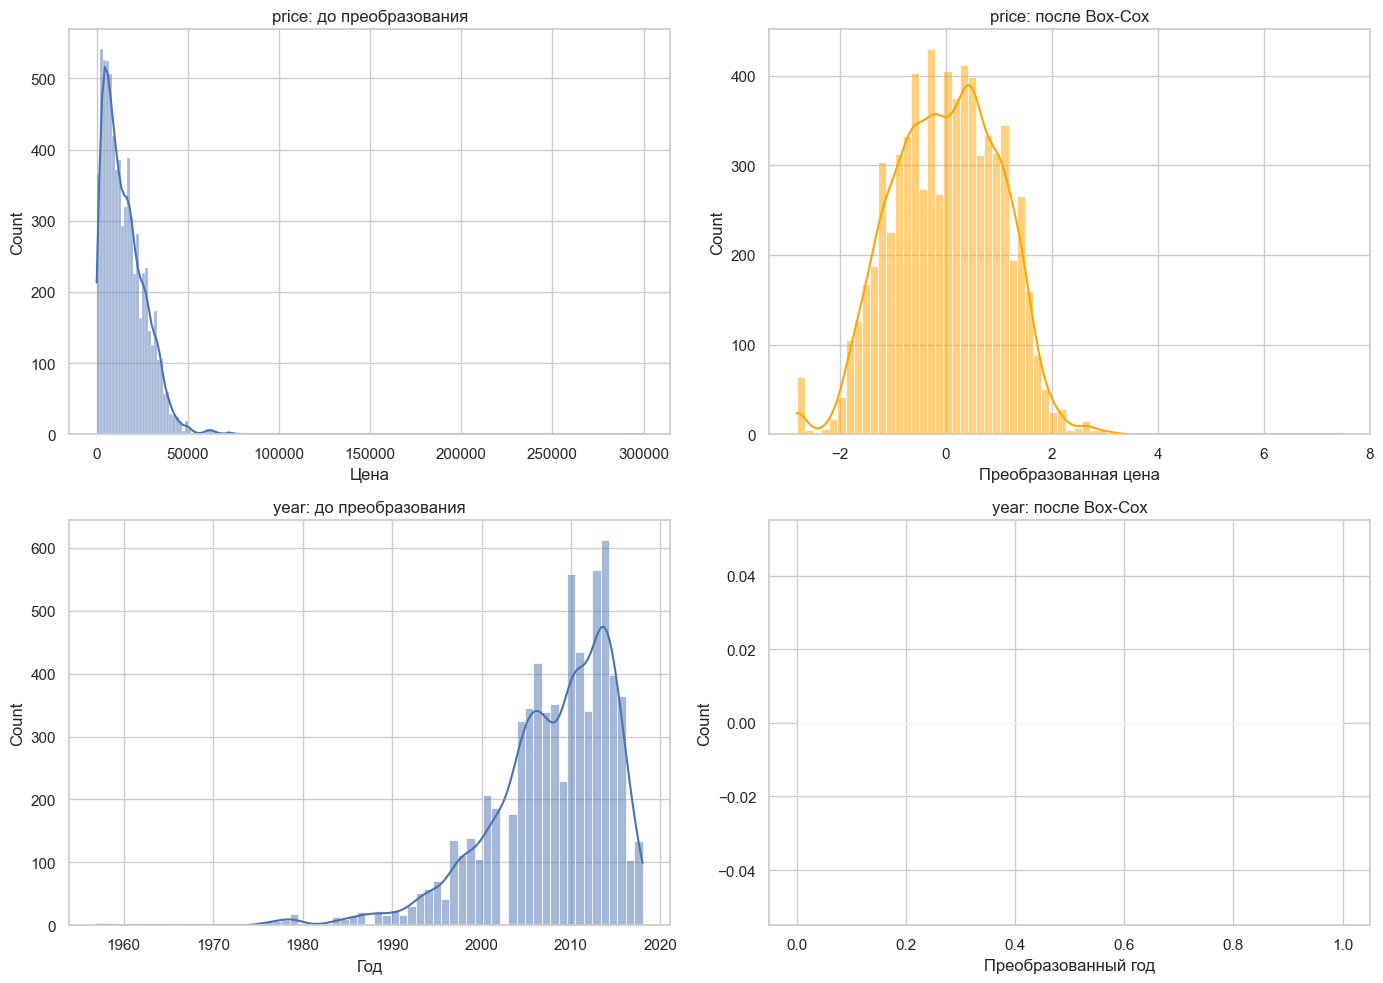

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns        
from sklearn.preprocessing import PowerTransformer
import scipy.stats as stats    # для QQ-plot

# Настройка стиля графиков
sns.set(style="whitegrid")

# Проверка колонок
required_cols = ['price', 'year']
for c in required_cols:
    if c not in data.columns:
        raise ValueError(f"В DataFrame отсутствует колонка '{c}'")

# Проверка на положительные значения (Box-Cox требует строго > 0)
for c in required_cols:
    if (data[c] <= 0).any():
        raise ValueError(f"Колонка '{c}' содержит значения <= 0. Box-Cox к ним неприменим.")

# Применяем PowerTransformer сразу к обеим колонкам
pt = PowerTransformer(method='box-cox')
transformed = pt.fit_transform(data[required_cols])

data_box_cox = pd.DataFrame(
    transformed,
    columns=[f'transformed_{c}' for c in required_cols],
    index=data.index
)

# --- Визуализация: гистограмма + KDE (до и после) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# price: до
sns.histplot(data=data, x='price', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('price: до преобразования')
axes[0, 0].set_xlabel('Цена')

# price: после
sns.histplot(data=data_box_cox, x='transformed_price', kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('price: после Box-Cox')
axes[0, 1].set_xlabel('Преобразованная цена')

# year: до
sns.histplot(data=data, x='year', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('year: до преобразования')
axes[1, 0].set_xlabel('Год')

# year: после
sns.histplot(data=data_box_cox, x='transformed_year', kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('year: после Box-Cox')
axes[1, 1].set_xlabel('Преобразованный год')

plt.tight_layout()
plt.show()

---

# <center> **Даты и расстояния**

По аналогии с датой и временем можно использовать информацию в столбцах, например, широту и долготу.

Давайте найдём конкретный адрес нулевого объекта, используя широту и долготу. Для этого нам понадобится библиотека ```geopy```.

In [189]:
from geopy.geocoders import Nominatim

Создаём объект ```Nominatim``` и инициализируем *API Nominatim* с помощью параметра ```geoapiExercises```.

In [190]:
geolocator = Nominatim(user_agent="geoapiExercises")

Объединим широту и долготу для поиска адреса нулевого объекта:

In [202]:
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderUnavailable, GeocoderServiceError
import time

# Инициализация с обязательным user_agent
geolocator = Nominatim(user_agent="my_data_science_project")

def safe_reverse_raw(lat, lon, max_retries=3):
    """
    Возвращает полный объект Location (с .address и .raw), а не просто строку.
    """
    for attempt in range(max_retries):
        try:
            # Важно: передаём координаты как "lat,lon" или отдельными аргументами
            location = geolocator.reverse(f"{lat},{lon}", timeout=10)
            
            if location:
                return location  # Возвращаем весь объект, а не только .address
            return None
            
        except (GeocoderUnavailable, GeocoderServiceError, ConnectionError) as e:
            if attempt == max_retries - 1:
                print(f"Все попытки исчерпаны. Ошибка: {e}")
                raise e
            # Экспоненциальная задержка: 2, 4, 8 секунд
            time.sleep(2 ** attempt)
    
    return None

# Пример использования
lat = data['lat'].iloc[0]
lon = data['long'].iloc[0]

location_obj = safe_reverse_raw(lat, lon)

if location_obj:
    # 1. Человекочитаемый адрес (как было раньше)
    print("Адрес строкой:", location_obj.address)
    
    # 2. Полный JSON-ответ (словарь)
    full_json = location_obj.raw
    print("\nПолный JSON-ответ (тип:", type(full_json), "):")
    print(full_json)
    
    # 3. Структурированный адрес
    if 'address' in full_json:
        structured_address = full_json['address']
        print("\nСтруктурированные поля:")
        for k, v in structured_address.items():
            print(f"  {k}: {v}")
else:
    print("Не удалось получить геоданные.")

Адрес строкой: Fort Henry Drive, Kingsport, Sullivan County, East Tennessee, Tennessee, 37663, United States

Полный JSON-ответ (тип: <class 'dict'> ):
{'place_id': 340149230, 'licence': 'Data © OpenStreetMap contributors, ODbL 1.0. http://osm.org/copyright', 'osm_type': 'way', 'osm_id': 111056101, 'lat': '36.4708081', 'lon': '-82.4844405', 'class': 'highway', 'type': 'primary', 'place_rank': 26, 'importance': 0.053374048218509156, 'addresstype': 'road', 'name': 'Fort Henry Drive', 'display_name': 'Fort Henry Drive, Kingsport, Sullivan County, East Tennessee, Tennessee, 37663, United States', 'address': {'road': 'Fort Henry Drive', 'city': 'Kingsport', 'county': 'Sullivan County', 'region': 'East Tennessee', 'state': 'Tennessee', 'ISO3166-2-lvl4': 'US-TN', 'postcode': '37663', 'country': 'United States', 'country_code': 'us'}, 'boundingbox': ['36.4425857', '36.4733840', '-82.4877113', '-82.4574896']}

Структурированные поля:
  road: Fort Henry Drive
  city: Kingsport
  county: Sullivan

Теперь получим информацию из данного списка и преобразуем её в словарь с помощью функции ```raw()```:

In [203]:
address = location_obj.raw['address']
address

{'road': 'Fort Henry Drive',
 'city': 'Kingsport',
 'county': 'Sullivan County',
 'region': 'East Tennessee',
 'state': 'Tennessee',
 'ISO3166-2-lvl4': 'US-TN',
 'postcode': '37663',
 'country': 'United States',
 'country_code': 'us'}

Если твоя цель — быстро превратить это в колонки DataFrame и избежать ошибок, если адрес не найден, используй такой шаблон:

In [204]:
def get_address_dict(lat, lon):
    loc = safe_reverse_raw(lat, lon)
    if not loc or not loc.raw or 'address' not in loc.raw:
        return None  # Или верни словарь с None-значениями
    return loc.raw['address']  # Это уже готовый словарь для pd.DataFrame([...])

# Применение к одной строке
addr_dict = get_address_dict(data['lat'].iloc[0], data['long'].iloc[0])

if addr_dict:
    df_row = pd.DataFrame([addr_dict])
    print(df_row.head())

               road       city           county          region      state   
0  Fort Henry Drive  Kingsport  Sullivan County  East Tennessee  Tennessee  \

  ISO3166-2-lvl4 postcode        country country_code  
0          US-TN    37663  United States           us  


Важные нюансы для массового применения
Учитывая твои прошлые задачи (ошибки типов, утечки, работа с большими датасетами):

Не запускай это в цикле по всему датасету без пауз. Nominatim блокирует IP за частые запросы. Если строк больше 50–100, обязательно оставляй time.sleep() между вызовами.
location.raw — это обычный Python‑словарь, а не JSON‑строка. Его можно сразу передавать в pd.DataFrame, не нужно делать json.loads().
Ключи могут отличаться. В разных странах Nominatim возвращает разные ключи (где-то есть suburb, где-то нет, где-то city, где-то town). Поэтому при создании DataFrame лучше не полагаться на жёсткий список колонок, а позволить pandas сам создать их из ключей словаря.

---

Задание 7.2
1/1 point (graded)

Найдите почтовый код шестого объекта выборки.

In [198]:
# Пример для одной строки
lat = data['lat'].iloc[5]
lon = data['long'].iloc[5]

location = safe_reverse(lat, lon)
print(location)

E&J Motors, 622, Southeast 82nd Avenue, Montavilla, Portland, Multnomah County, Oregon, 97216, United States


---

С помощью библиотек geopandas и shapely можно визуализировать географические данные. Это значит, что мы можем увидеть расположение наших объектов (автомобилей) на карте мира.

Установим данные библиотеки:
```python
!pip install geopandas
!pip install shapely

Отметим расположение объектов нашей выборки зелёным цветом.

In [205]:
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import matplotlib.pyplot as plt
 
geometry = [Point(xy) for xy in zip(data['long'], data['lat'])]
gdf = GeoDataFrame(data, geometry=geometry)  
 
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
gdf.plot(ax=world.plot(figsize=(15, 15)), marker='o', color='green', markersize=15)
 
plt.title('Расположение автомобилей на карте мира')
plt.show()

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

In [215]:
import folium

# Центр карты по медиане (устойчивее к выбросам, чем mean)
center_lat = data['lat'].median()
center_lon = data['long'].median()

m = folium.Map(location=[center_lat, center_lon], zoom_start=5)

# Рисуем только выборку (иначе браузер зависнет)
plot_data = data.dropna(subset=['lat', 'long'])
plot_data = plot_data[plot_data['lat'].between(-90, 90) & plot_data['long'].between(-180, 180)]
plot_sample = plot_data.sample(n=min(len(plot_data), 2000), random_state=42)

for _, row in plot_sample.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=4,
        color='green',
        fill=True,
        fill_opacity=0.7,
        tooltip=f"ID: {row.get('id', 'N/A')}"
    ).add_to(m)

m.save("cars_map.html")
print("Карта сохранена в cars_map.html — открой в браузере. Там сразу видно кластеры и выбросы.")

Карта сохранена в cars_map.html — открой в браузере. Там сразу видно кластеры и выбросы.


Скачиваем карту (с повторными попытками)...
Не удалось скачать карту даже с повторами: HTTPSConnectionPool(host='raw.githubusercontent.com', port=443): Max retries exceeded with url: /nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson (Caused by ProtocolError('Connection aborted.', ConnectionResetError(10054, 'Удаленный хост принудительно разорвал существующее подключение', None, 10054, None)))
Используем пустую базовую карту, чтобы не прерывать пайплайн.


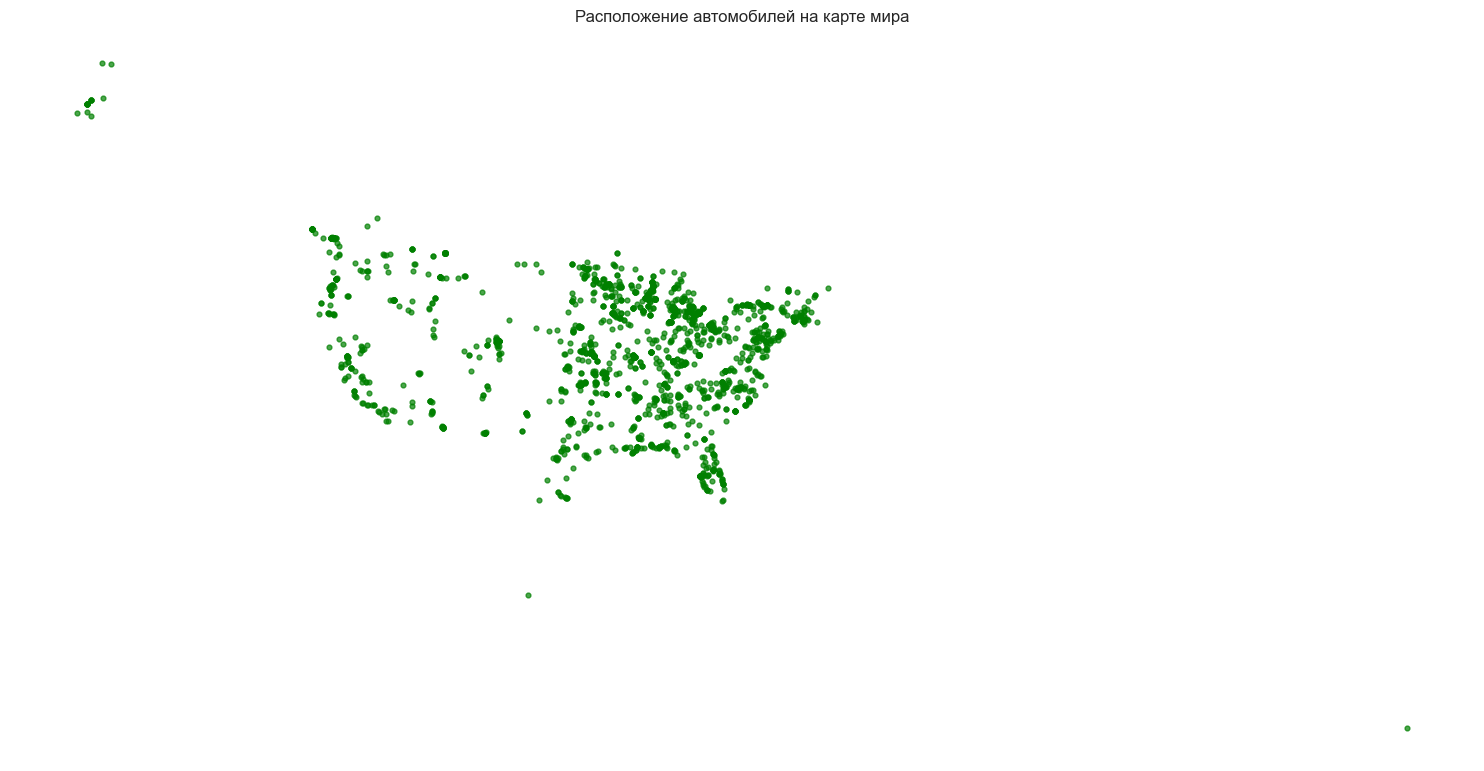

In [217]:
import io
import time
import requests
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import pandas as pd
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# --- Подготовка данных ---
mask = (
    data['lat'].notna() & 
    data['long'].notna() &
    data['lat'].between(-90, 90) & 
    data['long'].between(-180, 180)
)
data_clean = data[mask].copy()

if data_clean.empty:
    raise ValueError("Нет валидных координат после фильтрации!")

geometry = [Point(xy) for xy in zip(data_clean['long'], data_clean['lat'])]
gdf = gpd.GeoDataFrame(data_clean, geometry=geometry, crs="EPSG:4326")

# --- Настройка сессии с повторными попытками (retry) ---
def get_retry_session(retries=3, backoff_factor=2, status_forcelist=(429, 500, 502, 503, 504)):
    session = requests.Session()
    retry = Retry(
        total=retries,
        read=retries,
        connect=retries,
        backoff_factor=backoff_factor,
        status_forcelist=status_forcelist,
    )
    adapter = HTTPAdapter(max_retries=retry)
    session.mount("http://", adapter)
    session.mount("https://", adapter)
    return session

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
headers = {"User-Agent": "MyDataScienceProject/1.0"}

print("Скачиваем карту (с повторными попытками)...")
session = get_retry_session()
try:
    r = session.get(url, headers=headers, timeout=30)
    r.raise_for_status()
    world = gpd.read_file(io.BytesIO(r.content))
    print("Карта успешно загружена.")
except Exception as e:
    print(f"Не удалось скачать карту даже с повторами: {e}")
    # ЗАПАСНОЙ ВАРИАНТ: пустая карта — чтобы код не упал, а ты мог проверить точки отдельно
    print("Используем пустую базовую карту, чтобы не прерывать пайплайн.")
    world = gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")

# --- Построение ---
fig, ax = plt.subplots(figsize=(15, 10))

if not world.empty:
    world.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.5)

plot_gdf = gdf.sample(n=min(len(gdf), 2000), random_state=42) if len(gdf) > 2000 else gdf
plot_gdf.plot(ax=ax, marker='o', color='green', markersize=12, alpha=0.7)

plt.title('Расположение автомобилей на карте мира')
plt.axis('off')
plt.tight_layout()
plt.show()

С помощью Plotly мы можем построить интерактивную карту и отследить изменение цены автомобиля в зависимости от его локации:

In [218]:
import plotly.express as px
import pandas as pd
 
fig = px.scatter_geo(data,lat='lat',lon='long', hover_name="price")
fig.update_layout(title = 'Интерактивная карта цены автомобиля в зависимости от локации', title_x=1)
fig.show()

---